# Perception Question 1 — The Road Disappears

The aim of this task is to estimate the horizontal coordinate of the
lane centre at two image rows:

- Near row: v = 260
- Far row: v = 170

The three supplied sequences are:

1. clear
2. shadow
3. missing

I first build a simple baseline and run it unchanged on all 72 frames.
I then inspect its failures and make one revision to improve its behaviour
while also returning a confidence value.

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## A. Looking at the images before coding

Before designing the detector, I inspected one frame from each sequence.

The clear sequence shows two strong bright lane boundaries.

In the shadow sequence, part of one boundary becomes difficult to see
because the road intensity changes strongly.

In the missing sequence, one real boundary disappears while another
bright line inside the road can look like a valid lane boundary.

This means that using only a white-pixel threshold may work on clear
frames but can fail when visual evidence is incomplete or misleading.

In [ ]:
paths = [
    "data/city/lane/clear/000.png",
    "data/city/lane/shadow/008.png",
    "data/city/lane/missing/000.png"
]

titles = ["Clear", "Shadow", "Missing boundary"]

plt.figure(figsize=(15, 5))

for i in range(3):
    img = cv2.imread(paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)

    plt.axhline(260, linestyle="--")
    plt.axhline(170, linestyle="--")

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## B. Baseline lane-centre detector

I started with a simple brightness-based method.

At each required row, I use a small horizontal strip of 5 pixels instead of a single row. This makes the detector slightly less sensitive to one-pixel variations.

The steps are:

1. Convert the image to grayscale.
2. Look at a small strip around the required row.
3. Keep pixels brighter than a fixed threshold.
4. Group neighbouring bright pixels into candidate lane markings.
5. If two boundaries are available, estimate the lane centre as

\[
u_c = \frac{u_L + u_R}{2}
\]

If fewer than two reliable boundaries are found, the estimate is returned as unknown.

This baseline deliberately uses only local brightness information. It does not yet use previous frames or expected lane width.

In [5]:
def find_lane_center(gray, y, threshold=180):

    # take a small horizontal strip around the required row
    strip = gray[y-2:y+3, :]

    # brightness profile along horizontal direction
    profile = np.max(strip, axis=0)

    # locations that are bright enough to be lane markings
    bright_x = np.where(profile > threshold)[0]

    if len(bright_x) == 0:
        return None, []

    # group neighbouring bright pixels
    groups = []

    start = bright_x[0]
    previous = bright_x[0]

    for x in bright_x[1:]:

        if x == previous + 1:
            previous = x

        else:
            groups.append((start, previous))
            start = x
            previous = x

    groups.append((start, previous))

    # centre position of each detected bright line
    centers = []

    for start, end in groups:

        # ignore very tiny detections
        if end - start + 1 >= 2:

            center = float((start + end) / 2)

            # ignore detections very close to image edges
            if 60 < center < 420:
                centers.append(center)

    # baseline requires two boundaries
    if len(centers) < 2:
        return None, centers

    left_boundary = centers[0]
    right_boundary = centers[-1]

    lane_center = (left_boundary + right_boundary) / 2

    return lane_center, centers

In [6]:
test_paths = [
    "data/city/lane/clear/000.png",
    "data/city/lane/shadow/008.png",
    "data/city/lane/missing/000.png"
]

test_names = ["Clear", "Shadow", "Missing"]

near_y = 260
far_y = 170

for name, path in zip(test_names, test_paths):

    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    near_center, near_lines = find_lane_center(gray, near_y)
    far_center, far_lines = find_lane_center(gray, far_y)

    print(name)
    print("Near detected lines:", near_lines)
    print("Near centre:", near_center)

    print("Far detected lines:", far_lines)
    print("Far centre:", far_center)

    print()

Clear
Near detected lines: [112.0, 370.5]
Near centre: 241.25
Far detected lines: [161.5, 324.5]
Far centre: 243.0

Shadow
Near detected lines: [121.0, 379.0]
Near centre: 250.0
Far detected lines: [330.5]
Far centre: None

Missing
Near detected lines: [370.5]
Near centre: None
Far detected lines: [161.5, 189.0]
Far centre: 175.25



### Initial observations

The baseline works well on the clear frame because both road boundaries are bright and visible.

In the shadow frame, the near-row estimate is still available, but one boundary disappears at the far row. Since the baseline requires two boundaries, it returns `unknown`.

The missing-boundary frame shows a more serious failure. At the far row, the detector finds the real left boundary and a bright seam inside the road. It treats the seam as the second road boundary and therefore produces an incorrect lane-centre estimate.

This shows an important difference between two failure modes:

- returning `unknown` when evidence is insufficient;
- returning a confident-looking but incorrect value because the wrong visual feature was selected.

The second case is more dangerous for a controller because the numerical output appears valid.

## C. Running the baseline on all 72 frames

The same baseline is now applied without changing its threshold or logic to all 24 frames in each of the three sequences:

- clear
- shadow
- missing

For every frame, I store the near-row and far-row lane-centre estimates.

A missing value means that the detector did not find enough evidence to estimate the centre.

In [7]:
sequences = ["clear", "shadow", "missing"]

results = []

os.makedirs("outputs/q1", exist_ok=True)

for sequence in sequences:

    folder = "data/city/lane/" + sequence
    files = sorted(os.listdir(folder))

    for file in files:

        if not file.endswith(".png"):
            continue

        path = folder + "/" + file

        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        near_center, near_lines = find_lane_center(gray, near_y)
        far_center, far_lines = find_lane_center(gray, far_y)

        results.append({
            "sequence": sequence,
            "frame": file,
            "near_center": near_center,
            "far_center": far_center,
            "near_lines_found": len(near_lines),
            "far_lines_found": len(far_lines)
        })


baseline_df = pd.DataFrame(results)

baseline_df

,sequence,frame,near_center,far_center,near_lines_found,far_lines_found
0,clear,000.png,241.25,243.00,2,2
1,clear,001.png,242.50,244.00,2,2
2,clear,002.png,243.50,245.00,2,2
3,clear,003.png,244.75,245.75,2,2
4,clear,004.png,245.75,246.25,2,2
...,...,...,...,...,...,...
67,missing,019.png,254.50,185.75,2,2
68,missing,020.png,254.50,185.75,2,2
69,missing,021.png,254.25,185.50,2,2
70,missing,022.png,NaN,185.25,1,2


In [8]:
print("Total frames:", len(baseline_df))

baseline_df.to_csv(
    "outputs/q1/baseline_predictions.csv",
    index=False
)

print("Baseline predictions saved.")

Total frames: 72
Baseline predictions saved.


In [9]:
summary = []

for sequence in sequences:

    temp = baseline_df[baseline_df["sequence"] == sequence]

    near_unknown = temp["near_center"].isna().sum()
    far_unknown = temp["far_center"].isna().sum()

    summary.append({
        "sequence": sequence,
        "frames": len(temp),
        "near_unknown": near_unknown,
        "far_unknown": far_unknown
    })

unknown_summary = pd.DataFrame(summary)

unknown_summary

,sequence,frames,near_unknown,far_unknown
0,clear,24,0,0
1,shadow,24,5,12
2,missing,24,5,9


### Baseline coverage

The clear sequence produced estimates for most/all of the required rows.

The difficult sequences produced more unknown outputs, especially where a boundary became weak or disappeared.

However, unknown rate alone is not enough to judge the method. A detector can also return a numerical value based on the wrong line, as seen in the missing-boundary example. Therefore the predictions must also be compared with the provided reference values after the predictions have been fixed.

## D. Inspecting the visual evidence

To understand why the baseline succeeds or fails, I compare one clear frame with one difficult frame from the missing-boundary sequence.

The clear frame contains two strong lane boundaries. In the difficult frame, one real boundary is missing and a bright seam inside the road can be mistaken for the second boundary.

The following panel shows:
- the original image,
- the bright-pixel evidence used by the baseline,
- and the lane-centre estimate produced from that evidence.

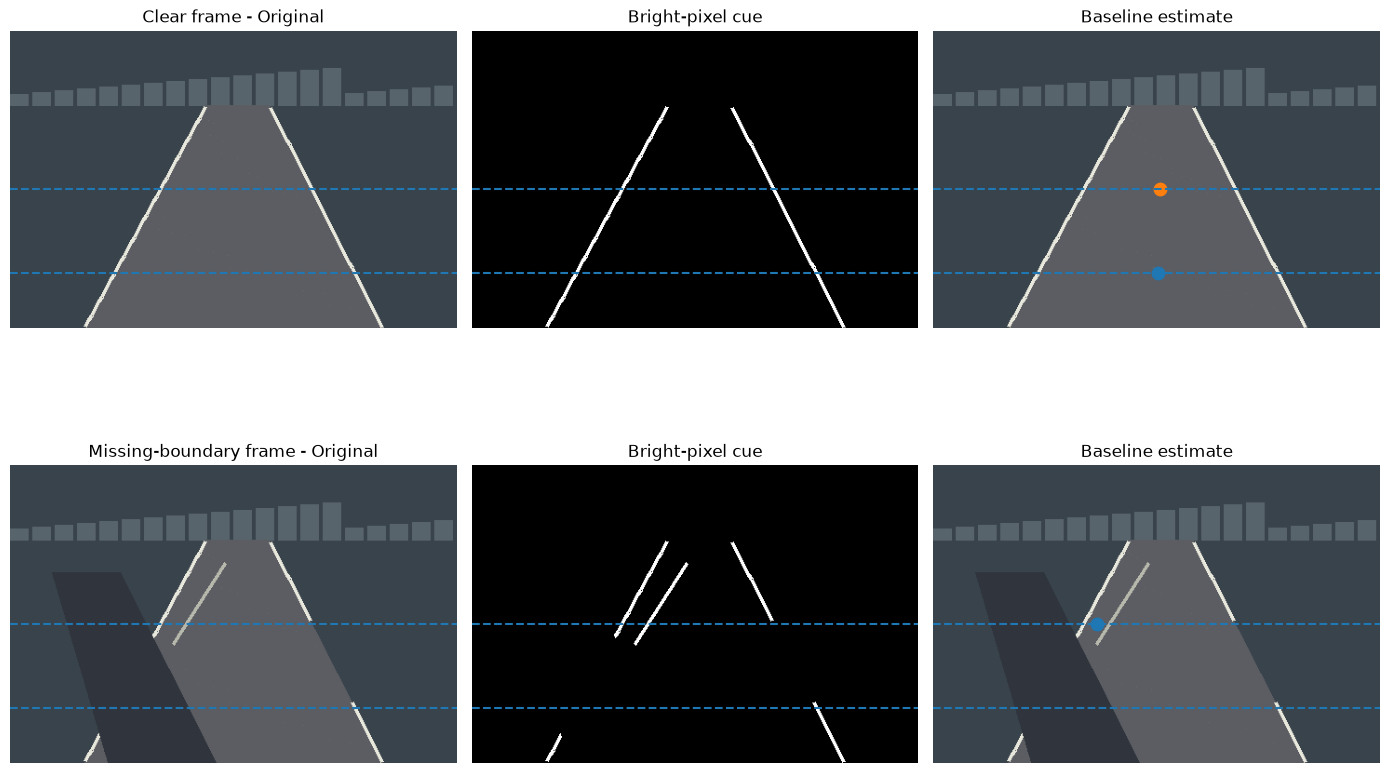

In [12]:
def get_bright_mask(img, threshold=180):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mask = np.zeros_like(gray)

    mask[gray > threshold] = 255

    return mask


compare_paths = [
    "data/city/lane/clear/000.png",
    "data/city/lane/missing/000.png"
]

compare_names = [
    "Clear frame",
    "Missing-boundary frame"
]

plt.figure(figsize=(14, 10))

for i in range(2):

    img = cv2.imread(compare_paths[i])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = get_bright_mask(img)

    near_center, near_lines = find_lane_center(gray, near_y)
    far_center, far_lines = find_lane_center(gray, far_y)

    # original image
    plt.subplot(2, 3, i*3 + 1)
    plt.imshow(img_rgb)
    plt.axhline(near_y, linestyle="--")
    plt.axhline(far_y, linestyle="--")
    plt.title(compare_names[i] + " - Original")
    plt.axis("off")

    # bright pixel cue
    plt.subplot(2, 3, i*3 + 2)
    plt.imshow(mask, cmap="gray")
    plt.axhline(near_y, linestyle="--")
    plt.axhline(far_y, linestyle="--")
    plt.title("Bright-pixel cue")
    plt.axis("off")

    # detected centre
    plt.subplot(2, 3, i*3 + 3)
    plt.imshow(img_rgb)

    plt.axhline(near_y, linestyle="--")
    plt.axhline(far_y, linestyle="--")

    if near_center is not None:
        plt.scatter(near_center, near_y, s=80)

    if far_center is not None:
        plt.scatter(far_center, far_y, s=80)

    plt.title("Baseline estimate")
    plt.axis("off")

plt.tight_layout()
plt.show()

### What the panel shows

In the clear frame, the thresholded image preserves both bright road boundaries, so the baseline can estimate the lane centre correctly.

In the missing-boundary frame, the real right boundary is absent at some rows. However, another bright seam inside the road survives the thresholding step. Because the baseline only checks brightness and horizontal position, it can mistake this seam for the second road boundary.

This explains why the baseline may produce a wrong numerical centre instead of returning `unknown`.

The failure suggests that brightness alone is not enough. The revised method should also use some knowledge of the expected road geometry, especially the expected distance between the two boundaries.

## E. Revised method

The main baseline failure came from treating every bright line as an equally plausible road boundary.

To repair this, I added two simple geometric and temporal cues:

1. **Expected lane width:**  
   A clear calibration frame is used to estimate the normal separation between the left and right boundaries at the near and far rows. The reference labels are not used for this.

2. **Previous centre:**  
   The previous frame's estimate is used as a weak temporal prior. A sudden large shift in lane centre is treated as suspicious.

For each row, the revised method first looks for a pair of detected lines whose separation is close to the expected lane width.

If only one plausible boundary is visible, the missing boundary is inferred using the expected lane width.

If the available bright line would imply an implausibly large jump, the detector does not trust it. It temporarily keeps the previous centre with a low confidence score.

The confidence value is only a ranking of trust, not a calibrated probability.

In [13]:
calib_path = "data/city/lane/clear/000.png"

calib_img = cv2.imread(calib_path)
calib_gray = cv2.cvtColor(calib_img, cv2.COLOR_BGR2GRAY)

_, near_candidates = find_lane_center(calib_gray, near_y)
_, far_candidates = find_lane_center(calib_gray, far_y)

expected_near_width = near_candidates[-1] - near_candidates[0]
expected_far_width = far_candidates[-1] - far_candidates[0]

initial_near_center = (near_candidates[0] + near_candidates[-1]) / 2
initial_far_center = (far_candidates[0] + far_candidates[-1]) / 2

print("Expected near lane width:", expected_near_width)
print("Expected far lane width:", expected_far_width)

print("Initial near centre:", initial_near_center)
print("Initial far centre:", initial_far_center)

Expected near lane width: 258.5
Expected far lane width: 163.0
Initial near centre: 241.25
Initial far centre: 243.0


In [14]:
def revised_lane_center(gray, y, expected_width, previous_center,
                        threshold=180, width_tolerance=0.25,
                        max_jump=15):

    # get all bright-line candidates
    _, candidates = find_lane_center(gray, y, threshold)

    best_center = None
    best_score = 999
    best_width_error = None

    # first try to find a pair with realistic lane width
    for i in range(len(candidates)):

        for j in range(i + 1, len(candidates)):

            left = candidates[i]
            right = candidates[j]

            width = right - left

            width_error = abs(width - expected_width) / expected_width

            center = (left + right) / 2

            if previous_center is not None:
                jump = abs(center - previous_center)
            else:
                jump = 0

            # prefer correct width and temporal consistency
            score = width_error + 0.01 * jump

            if width_error <= width_tolerance and score < best_score:

                best_score = score
                best_center = center
                best_width_error = width_error


    # case 1: two trustworthy boundaries found
    if best_center is not None:

        confidence = 1 - best_width_error

        if confidence < 0.75:
            confidence = 0.75

        if confidence > 1:
            confidence = 1

        return best_center, confidence, candidates, "two boundaries"


    # case 2: try using one boundary + expected road width
    if previous_center is not None and len(candidates) > 0:

        best_inferred_center = None
        smallest_jump = 999

        for line in candidates:

            # assume detected line is left boundary
            center_from_left = line + expected_width / 2

            jump_left = abs(center_from_left - previous_center)

            if jump_left < smallest_jump:
                smallest_jump = jump_left
                best_inferred_center = center_from_left


            # assume detected line is right boundary
            center_from_right = line - expected_width / 2

            jump_right = abs(center_from_right - previous_center)

            if jump_right < smallest_jump:
                smallest_jump = jump_right
                best_inferred_center = center_from_right


        if smallest_jump <= max_jump:

            return (
                best_inferred_center,
                0.60,
                candidates,
                "one boundary + width prior"
            )


    # case 3: evidence is not trustworthy
    # keep previous estimate but mark it low confidence
    if previous_center is not None:

        return (
            previous_center,
            0.35,
            candidates,
            "temporal fallback"
        )


    # no usable information
    return None, 0.0, candidates, "unknown"

In [15]:
path = "data/city/lane/missing/000.png"

img = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

near_result = revised_lane_center(
    gray,
    near_y,
    expected_near_width,
    initial_near_center
)

far_result = revised_lane_center(
    gray,
    far_y,
    expected_far_width,
    initial_far_center
)

print("Near:")
print("Centre:", near_result[0])
print("Confidence:", near_result[1])
print("Candidates:", near_result[2])
print("Reason:", near_result[3])

print()

print("Far:")
print("Centre:", far_result[0])
print("Confidence:", far_result[1])
print("Candidates:", far_result[2])
print("Reason:", far_result[3])

Near:
Centre: 241.25
Confidence: 0.6
Candidates: [370.5]
Reason: one boundary + width prior

Far:
Centre: 243.0
Confidence: 0.6
Candidates: [161.5, 189.0]
Reason: one boundary + width prior


### Effect on the earlier failure

In the missing-boundary frame, the baseline returned an incorrect far-row centre because it paired the real left boundary with the bright internal seam.

The revised method rejects this pair because its separation is much smaller than the expected road width.

Instead, it uses the boundary that gives a lane centre consistent with the previously observed road geometry and reconstructs the missing side using the width prior.

The estimate therefore receives medium confidence rather than the high confidence associated with observing two consistent boundaries.

In [16]:
revised_results = []

for sequence in sequences:

    folder = "data/city/lane/" + sequence
    files = sorted(os.listdir(folder))

    # starting geometric prior
    previous_near = initial_near_center
    previous_far = initial_far_center

    for file in files:

        if not file.endswith(".png"):
            continue

        path = folder + "/" + file

        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


        near_center, near_conf, near_lines, near_reason = revised_lane_center(
            gray,
            near_y,
            expected_near_width,
            previous_near
        )


        far_center, far_conf, far_lines, far_reason = revised_lane_center(
            gray,
            far_y,
            expected_far_width,
            previous_far
        )


        revised_results.append({
            "sequence": sequence,
            "frame": file,

            "near_center": near_center,
            "far_center": far_center,

            "near_confidence": near_conf,
            "far_confidence": far_conf,

            "near_reason": near_reason,
            "far_reason": far_reason
        })


        # only use current result for the next frame
        if near_center is not None:
            previous_near = near_center

        if far_center is not None:
            previous_far = far_center


revised_df = pd.DataFrame(revised_results)

revised_df

,sequence,frame,near_center,far_center,near_confidence,far_confidence,near_reason,far_reason
0,clear,000.png,241.25,243.00,1.000000,1.000000,two boundaries,two boundaries
1,clear,001.png,242.50,244.00,0.998066,1.000000,two boundaries,two boundaries
2,clear,002.png,243.50,245.00,0.998066,1.000000,two boundaries,two boundaries
3,clear,003.png,244.75,245.75,0.996132,0.996933,two boundaries,two boundaries
4,clear,004.png,245.75,246.25,0.996132,0.996933,two boundaries,two boundaries
...,...,...,...,...,...,...,...,...
67,missing,019.png,254.50,251.00,0.998066,0.600000,two boundaries,one boundary + width prior
68,missing,020.png,254.50,251.00,0.998066,0.600000,two boundaries,one boundary + width prior
69,missing,021.png,254.25,250.50,0.996132,0.600000,two boundaries,one boundary + width prior
70,missing,022.png,254.25,250.00,0.600000,0.600000,one boundary + width prior,one boundary + width prior


In [17]:
revised_df.to_csv(
    "outputs/q1/revised_predictions.csv",
    index=False
)

print("Total revised predictions:", len(revised_df))
print("Revised predictions saved.")

Total revised predictions: 72
Revised predictions saved.


In [18]:
print("Near-row decisions:")
print(revised_df["near_reason"].value_counts())

print()

print("Far-row decisions:")
print(revised_df["far_reason"].value_counts())

Near-row decisions:
near_reason
two boundaries                62
one boundary + width prior    10
Name: count, dtype: int64

Far-row decisions:
far_reason
two boundaries                36
one boundary + width prior    27
temporal fallback              9
Name: count, dtype: int64


## F. Evaluation using the reference coordinates

The baseline and revised predictions were fixed before opening the reference file.

I now use `lane_reference.csv` only for evaluation.

For each sequence and each image row, I calculate:

- **Mean Absolute Error (MAE)** in pixels on frames where a coordinate was returned.
- **Unknown rate**, which is the fraction of frames for which no coordinate was returned.

Reporting both values is important because a detector should not appear accurate simply by refusing to make predictions on difficult frames.


In [19]:
reference_df = pd.read_csv("data/city/lane_reference.csv")

reference_df.head()

,sequence,frame,near_y_px,near_center_x_px,far_y_px,far_center_x_px
0,clear,0,260,241.16,170,242.93
1,clear,1,260,242.38,170,243.85
2,clear,2,260,243.58,170,244.75
3,clear,3,260,244.76,170,245.61
4,clear,4,260,245.91,170,246.43


In [20]:
baseline_eval = baseline_df.copy()
revised_eval = revised_df.copy()

baseline_eval["frame_num"] = (
    baseline_eval["frame"]
    .str.replace(".png", "", regex=False)
    .astype(int)
)

revised_eval["frame_num"] = (
    revised_eval["frame"]
    .str.replace(".png", "", regex=False)
    .astype(int)
)


baseline_eval = baseline_eval.merge(
    reference_df,
    left_on=["sequence", "frame_num"],
    right_on=["sequence", "frame"]
)

revised_eval = revised_eval.merge(
    reference_df,
    left_on=["sequence", "frame_num"],
    right_on=["sequence", "frame"]
)

print("Baseline rows:", len(baseline_eval))
print("Revised rows:", len(revised_eval))

Baseline rows: 72
Revised rows: 72


In [21]:
def calculate_metrics(df, method_name):

    rows = []

    for sequence in sequences:

        temp = df[df["sequence"] == sequence]

        # near row
        valid_near = temp["near_center"].notna()

        near_mae = np.mean(
            np.abs(
                temp.loc[valid_near, "near_center"]
                - temp.loc[valid_near, "near_center_x_px"]
            )
        )

        near_unknown = 1 - valid_near.mean()


        # far row
        valid_far = temp["far_center"].notna()

        far_mae = np.mean(
            np.abs(
                temp.loc[valid_far, "far_center"]
                - temp.loc[valid_far, "far_center_x_px"]
            )
        )

        far_unknown = 1 - valid_far.mean()


        rows.append({
            "method": method_name,
            "sequence": sequence,
            "row": "near",
            "MAE_px": near_mae,
            "unknown_rate": near_unknown
        })


        rows.append({
            "method": method_name,
            "sequence": sequence,
            "row": "far",
            "MAE_px": far_mae,
            "unknown_rate": far_unknown
        })


    return pd.DataFrame(rows)

In [22]:
baseline_metrics = calculate_metrics(
    baseline_eval,
    "Baseline"
)

revised_metrics = calculate_metrics(
    revised_eval,
    "Revised"
)

metrics = pd.concat(
    [baseline_metrics, revised_metrics],
    ignore_index=True
)

metrics["MAE_px"] = metrics["MAE_px"].round(2)
metrics["unknown_rate"] = metrics["unknown_rate"].round(3)

metrics

,method,sequence,row,MAE_px,unknown_rate
0,Baseline,clear,near,0.11,0.000
1,Baseline,clear,far,0.16,0.000
2,Baseline,shadow,near,0.17,0.208
3,Baseline,shadow,far,0.29,0.500
4,Baseline,missing,near,0.17,0.208
5,Baseline,missing,far,65.82,0.375
6,Revised,clear,near,0.11,0.000
7,Revised,clear,far,0.16,0.000
8,Revised,shadow,near,0.19,0.000
9,Revised,shadow,far,0.24,0.000


In [23]:
metrics.to_csv(
    "outputs/q1/baseline_vs_revised_metrics.csv",
    index=False
)

print("Metrics saved.")

Metrics saved.


### Evaluation result

The baseline performs very well on the clear sequence because both lane boundaries remain strong and visible.

The shadow sequence mainly causes missing detections. The baseline often returns `unknown`, particularly at the far row, rather than producing a strongly incorrect coordinate.

The most important failure occurs in the missing-boundary sequence. At the far row, the baseline sometimes accepts the bright internal seam as a road boundary. This produces a large error even though the detector returns a valid-looking numerical coordinate.

The revised method greatly reduces this error by checking whether the detected boundary separation is consistent with the expected road width. When only one trustworthy boundary is available, the missing side is inferred using the width prior.

The revision also reduces the unknown rate because it can use one visible boundary or short-term temporal information. This improvement comes with a limitation: if both boundaries remain absent for a long time while the road geometry changes, a temporal fallback can become stale.

## G. Lane-centre estimates through the missing sequence

The following plot compares the near-row lane-centre estimate through all 24 frames of the missing-boundary sequence.

Both the baseline and revised estimates are shown against the reference coordinates.

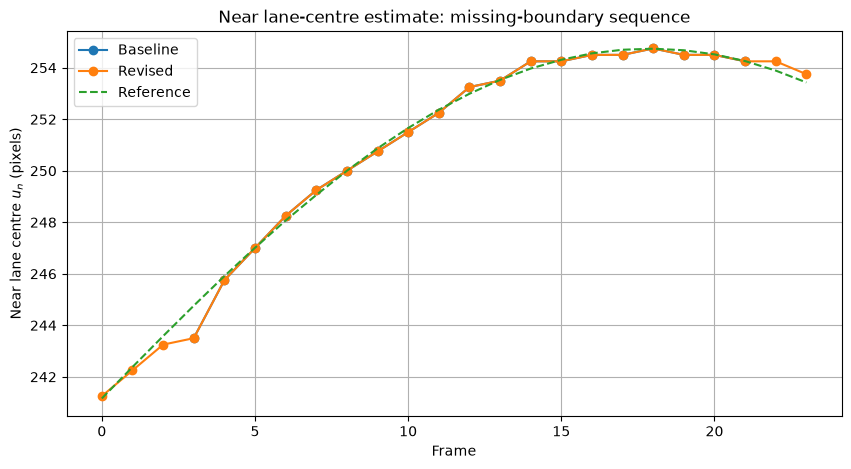

In [25]:
baseline_missing = baseline_eval[
    baseline_eval["sequence"] == "missing"
].copy()

revised_missing = revised_eval[
    revised_eval["sequence"] == "missing"
].copy()


plt.figure(figsize=(10, 5))

plt.plot(
    baseline_missing["frame_num"],
    baseline_missing["near_center"],
    marker="o",
    label="Baseline"
)

plt.plot(
    revised_missing["frame_num"],
    revised_missing["near_center"],
    marker="o",
    label="Revised"
)

plt.plot(
    revised_missing["frame_num"],
    revised_missing["near_center_x_px"],
    linestyle="--",
    label="Reference"
)

plt.xlabel("Frame")
plt.ylabel("Near lane centre $u_n$ (pixels)")
plt.title("Near lane-centre estimate: missing-boundary sequence")

plt.legend()
plt.grid()

plt.show()

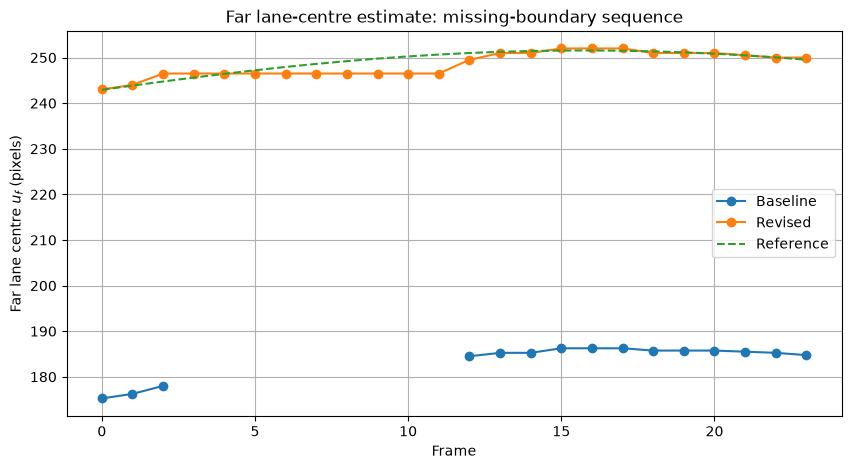

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_missing["frame_num"],
    baseline_missing["far_center"],
    marker="o",
    label="Baseline"
)

plt.plot(
    revised_missing["frame_num"],
    revised_missing["far_center"],
    marker="o",
    label="Revised"
)

plt.plot(
    revised_missing["frame_num"],
    revised_missing["far_center_x_px"],
    linestyle="--",
    label="Reference"
)

plt.xlabel("Frame")
plt.ylabel("Far lane centre $u_f$ (pixels)")
plt.title("Far lane-centre estimate: missing-boundary sequence")

plt.legend()
plt.grid()

plt.show()

## H. Annotated examples from all three sequences

The following examples show the estimated road geometry at both required rows.

The centre point is the lane centre used by the revised method. The two boundary points are reconstructed from the expected road width when one boundary is not directly visible.

This makes the assumed continuation of a missing boundary explicit instead of hiding it inside the code.

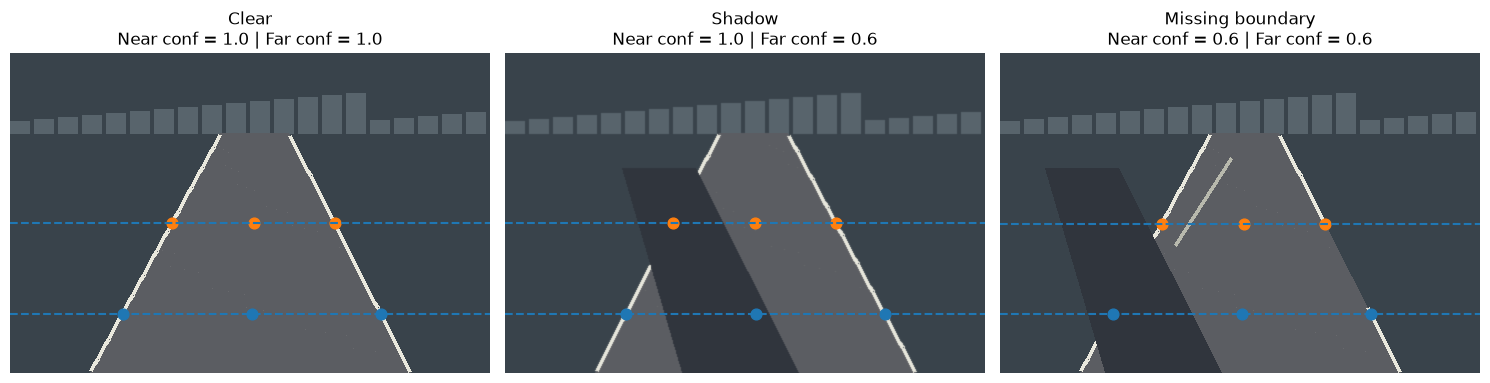

In [27]:
def show_annotated_frame(path, title, prev_near, prev_far):

    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    near_center, near_conf, near_lines, near_reason = revised_lane_center(
        gray,
        near_y,
        expected_near_width,
        prev_near
    )

    far_center, far_conf, far_lines, far_reason = revised_lane_center(
        gray,
        far_y,
        expected_far_width,
        prev_far
    )

    plt.imshow(img_rgb)

    plt.axhline(near_y, linestyle="--")
    plt.axhline(far_y, linestyle="--")

    if near_center is not None:

        near_left = near_center - expected_near_width / 2
        near_right = near_center + expected_near_width / 2

        plt.scatter(
            [near_left, near_center, near_right],
            [near_y, near_y, near_y],
            s=60
        )

    if far_center is not None:

        far_left = far_center - expected_far_width / 2
        far_right = far_center + expected_far_width / 2

        plt.scatter(
            [far_left, far_center, far_right],
            [far_y, far_y, far_y],
            s=60
        )

    plt.title(
        title +
        "\nNear conf = " + str(round(near_conf, 2)) +
        " | Far conf = " + str(round(far_conf, 2))
    )

    plt.axis("off")


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
show_annotated_frame(
    "data/city/lane/clear/000.png",
    "Clear",
    initial_near_center,
    initial_far_center
)

plt.subplot(1, 3, 2)
show_annotated_frame(
    "data/city/lane/shadow/008.png",
    "Shadow",
    initial_near_center,
    initial_far_center
)

plt.subplot(1, 3, 3)
show_annotated_frame(
    "data/city/lane/missing/000.png",
    "Missing boundary",
    initial_near_center,
    initial_far_center
)

plt.tight_layout()

plt.savefig(
    "outputs/q1/annotated_sequences.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## I. Confidence rule

The confidence value is a ranking of how much I trust an estimate. It is not treated as a calibrated probability.

I use three main confidence levels:

- When two boundaries agree with the expected road width, confidence is high.
- When only one boundary is visible and the other has to be reconstructed using the lane-width prior, confidence is medium.
- When current-frame evidence is not trustworthy and the previous estimate has to be reused, confidence is low.

This prevents a temporarily usable fallback from being treated as equally reliable as two directly observed boundaries.

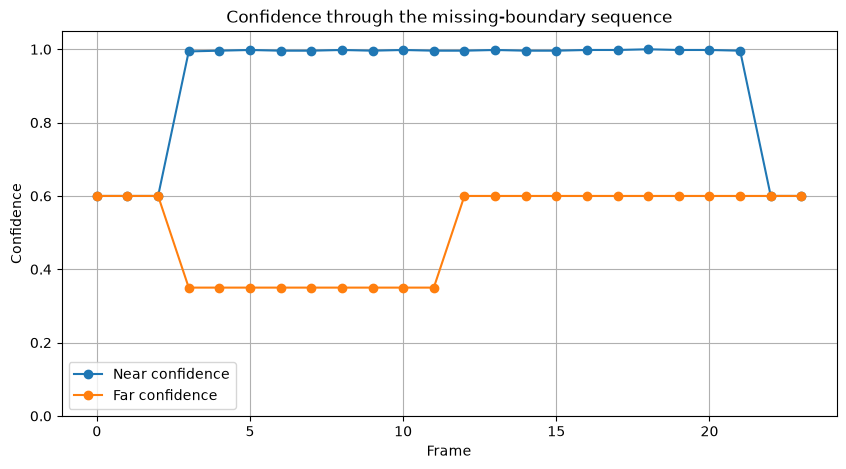

In [28]:
missing_conf = revised_df[
    revised_df["sequence"] == "missing"
].copy()

missing_conf["frame_num"] = (
    missing_conf["frame"]
    .str.replace(".png", "", regex=False)
    .astype(int)
)

plt.figure(figsize=(10, 5))

plt.plot(
    missing_conf["frame_num"],
    missing_conf["near_confidence"],
    marker="o",
    label="Near confidence"
)

plt.plot(
    missing_conf["frame_num"],
    missing_conf["far_confidence"],
    marker="o",
    label="Far confidence"
)

plt.xlabel("Frame")
plt.ylabel("Confidence")
plt.ylim(0, 1.05)

plt.title("Confidence through the missing-boundary sequence")

plt.legend()
plt.grid()

plt.savefig(
    "outputs/q1/missing_sequence_confidence.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## J. Two baseline failure cases

I selected two different types of failure.

**Failure 1 — Shadow:**  
One boundary becomes too weak at the far row. The baseline finds only one candidate and therefore returns `unknown`.

**Failure 2 — False seam in missing sequence:**  
One real boundary disappears, while a bright seam remains visible inside the road. The baseline treats the seam as a real road boundary and returns a numerical lane centre that is strongly incorrect.

The second case is more dangerous because it does not look like a failure from the output alone.

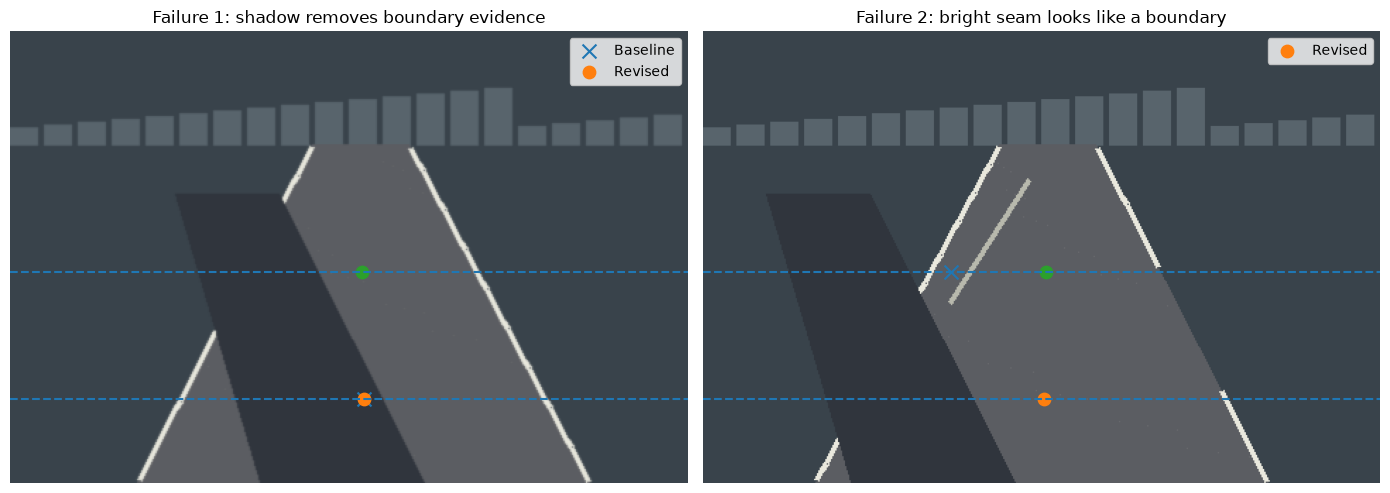

In [29]:
failure_paths = [
    "data/city/lane/shadow/008.png",
    "data/city/lane/missing/000.png"
]

failure_titles = [
    "Failure 1: shadow removes boundary evidence",
    "Failure 2: bright seam looks like a boundary"
]

plt.figure(figsize=(14, 6))

for i in range(2):

    img = cv2.imread(failure_paths[i])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    baseline_near, _ = find_lane_center(gray, near_y)
    baseline_far, _ = find_lane_center(gray, far_y)

    revised_near = revised_lane_center(
        gray,
        near_y,
        expected_near_width,
        initial_near_center
    )[0]

    revised_far = revised_lane_center(
        gray,
        far_y,
        expected_far_width,
        initial_far_center
    )[0]


    plt.subplot(1, 2, i + 1)

    plt.imshow(img_rgb)

    plt.axhline(near_y, linestyle="--")
    plt.axhline(far_y, linestyle="--")


    if baseline_near is not None:
        plt.scatter(
            baseline_near,
            near_y,
            marker="x",
            s=100,
            label="Baseline"
        )

    if baseline_far is not None:
        plt.scatter(
            baseline_far,
            far_y,
            marker="x",
            s=100
        )


    if revised_near is not None:
        plt.scatter(
            revised_near,
            near_y,
            marker="o",
            s=80,
            label="Revised"
        )

    if revised_far is not None:
        plt.scatter(
            revised_far,
            far_y,
            marker="o",
            s=80
        )


    plt.title(failure_titles[i])
    plt.axis("off")
    plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/q1/failure_examples.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## K. Conclusion

A simple brightness threshold was a useful baseline because it worked very well when both lane boundaries were clearly visible. Its main weakness was that it had no way to distinguish a true road boundary from another bright line in the image.

The revised method added expected lane width and short-term temporal consistency. This allowed it to reject the false seam, reconstruct a temporarily missing boundary, and reduce the number of unknown outputs.

The improvement is intentionally simple and explainable. It does not solve lane detection in general. In particular, the temporal fallback may become stale if both boundaries remain invisible for several frames while the road is changing rapidly.

For the supplied sequences, however, the evaluation shows that adding geometric consistency makes the detector substantially more reliable on the difficult frames without requiring a trained model.

In [30]:
print("Q1 files generated:")

for file in sorted(os.listdir("outputs/q1")):
    print(file)

Q1 files generated:
annotated_sequences.png
baseline_predictions.csv
baseline_vs_revised_metrics.csv
failure_examples.png
missing_sequence_confidence.png
revised_predictions.csv
